In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import scipy as sp
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from source.SecludedDM import Cosmology, VectorPortal, BoltzmannSolver, find_mXstar

plt.style.use('/home/gab/Desktop/PyCharm_env/mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False

In [2]:
def load_relic(fname):
    with open(fname) as f:
        params = dict(s.split('=') for s in f.readline().lstrip('# ').split())
    mXs, mYs, epsXs, epsXs_bbn = np.loadtxt(fname).T
    return {**{k: float(v) for k, v in params.items()},
            'mXs': mXs, 'mYs': mYs, 'epsXs': epsXs, 'epsXs_bbn': epsXs_bbn}

In [10]:
aXs_rs_str=['aX1e-03_r1.5','aX1e-03_r5.0','aX5e-03_r1.5','aX5e-03_r5.0']
aXs_rs_vals=np.array([[1e-3,1.5],[1e-3,5],[5e-3,1.5],[5e-3,5]])

In [11]:
dats=[]
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
for i in range(len(aXs_rs_str)):
    dat1 = load_relic("../output/vP/relic_"+str(aXs_rs_str[i])+".dat")
    mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
    mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
    epsXs1 = np.concatenate([[1e-1, dat1['epsX_min']],    epsXs1])
    mXs_bbn_dd=np.logspace(np.log10(min([2,min(mXs1)])),np.log10(max(mXs1)),1000)
    bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
    epsXs_bbn=bbn_bound(mXs_bbn_dd)
    epsXs_LZ=np.ones(len(mXs_bbn_dd))
    epsXs_nu=np.ones(len(mXs_bbn_dd))
    for j in trange(len(mXs_bbn_dd)):
        model = VectorPortal(
            mX=mXs_bbn_dd[j],       
            mY=mXs_bbn_dd[j]/aXs_rs_vals[i][1],       
            alphaX=aXs_rs_vals[i][0]
        )
        solver = BoltzmannSolver(cosmo, model)
        try:
            epsXs_LZ[j]= solver.find_epsilon_DD(constraint='LZ',log10eps_range=(-9,0))
            epsXs_nu[j] = solver.find_epsilon_DD(constraint='nufloor_Xe',log10eps_range=(-9,0))
        except:
            continue
    Dict={'mXs':mXs1,'epsXs':epsXs1,'mXs_bbn_dd':mXs_bbn_dd,'epsXs_bbn':epsXs_bbn,'epsXs_LZ':epsXs_LZ,'epsXs_nu':epsXs_nu}
    dats.append(Dict)
    del Dict

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4567.98it/s]


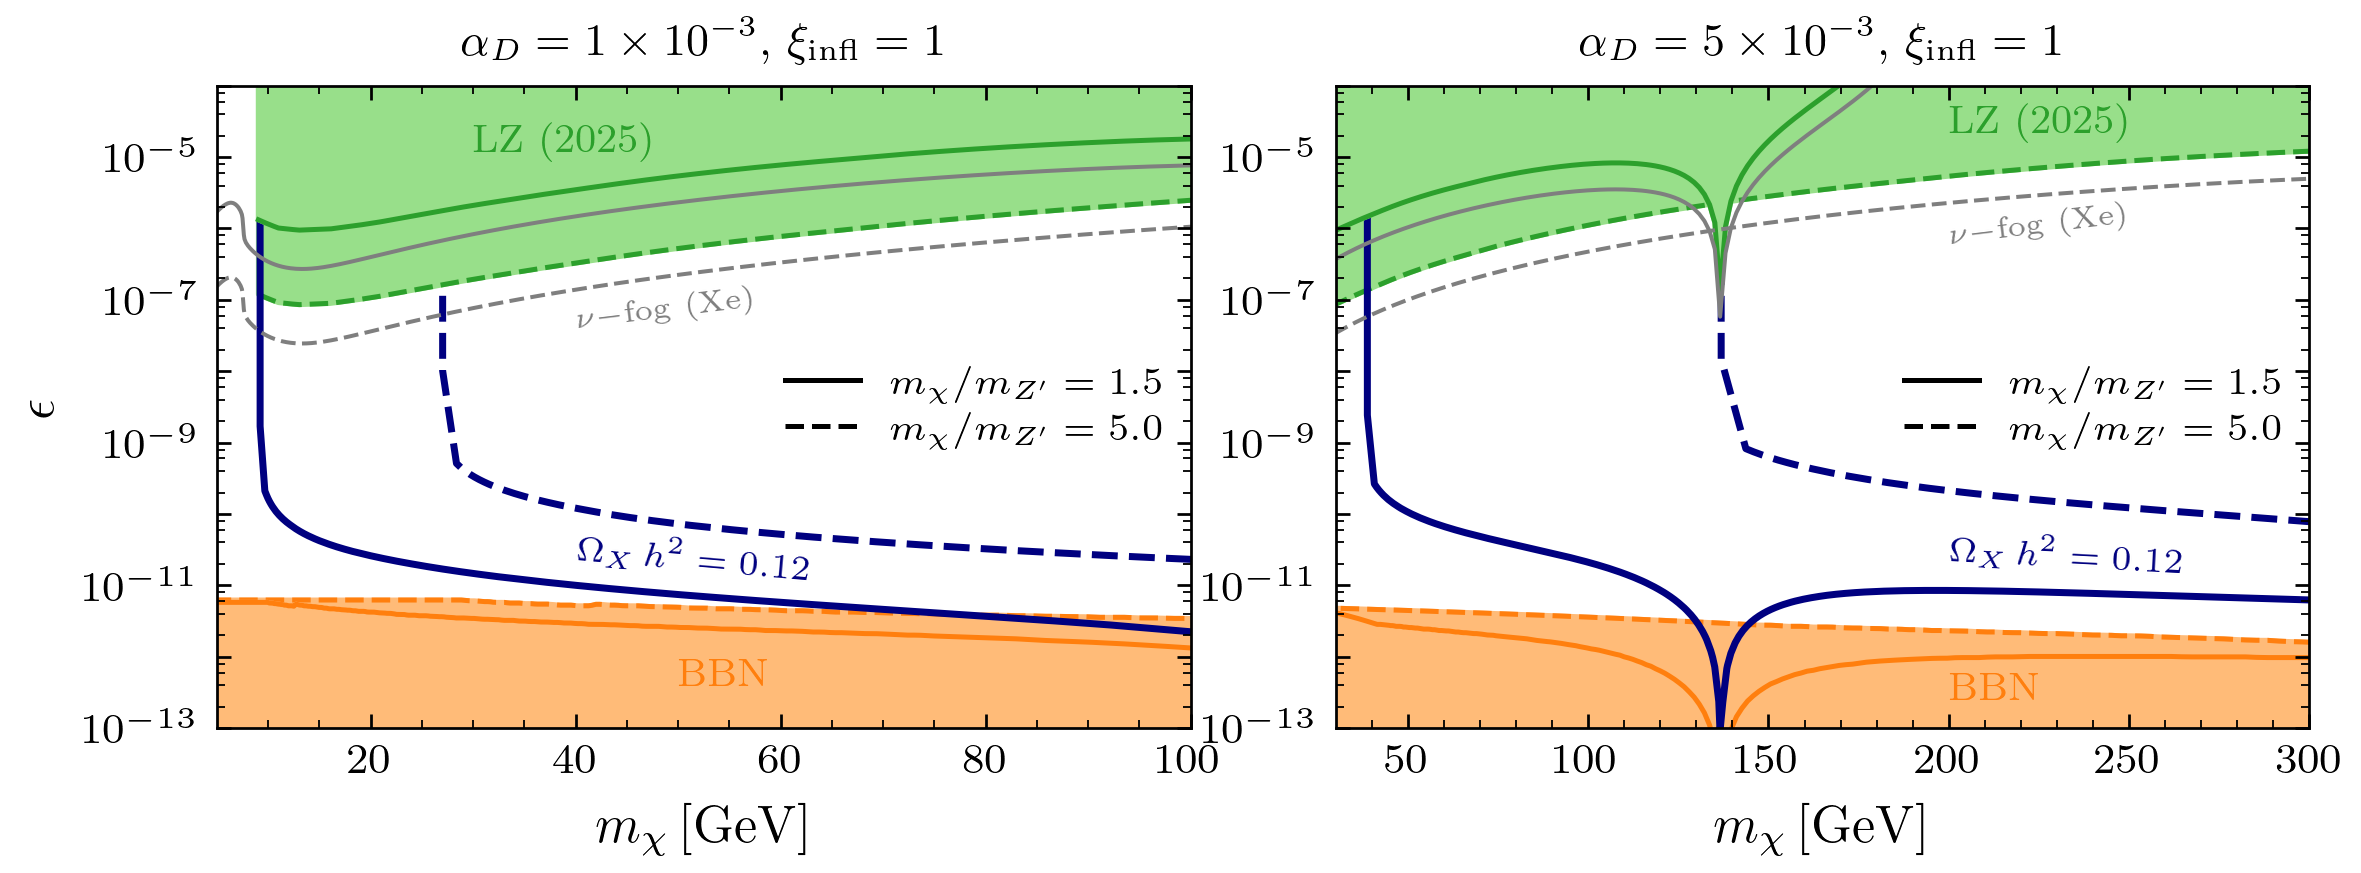

In [13]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(20,17,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:8])
ax2 = fig1.add_subplot(gs1[:,9:])
lss=['-','--']
ZOs=[[-0.8,-.7],[-1,-0.9]]

for j in range(2):
    ax1.plot(dats[j]['mXs'],dats[j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax1.fill_between(dats[j]['mXs_bbn_dd'],0, dats[j]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    ax1.fill_between(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
    ax2.plot(dats[2+j]['mXs'],dats[2+j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax2.fill_between(dats[2+j]['mXs_bbn_dd'],0, dats[2+j]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    ax2.fill_between(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel("$\epsilon$")
axs=[ax1,ax2]
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-13,1e-4)
    ax.set_yticks([1e-13,1e-12,1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4])
    ax.set_yticklabels(['$10^{-13}$','','$10^{-11}$','','$10^{-9}$','','$10^{-7}$','','$10^{-5}$',''])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.plot(np.NaN,np.NaN,ls='-',lw=1,c='k',label='$m_\chi/m_{Z^\prime}=1.5$')
    ax.plot(np.NaN,np.NaN,ls='--',lw=1,c='k',label='$m_\chi/m_{Z^\prime}=5.0$')
    ax.legend()
    ax.set_xlabel(r"$m_\chi\,[{\rm GeV}]$")
ax1.set_title(r'$\alpha_D=1\times 10^{-3},\,\xi_{\rm infl}=1$',fontsize=9)
ax2.set_title(r'$\alpha_D=5\times 10^{-3},\,\xi_{\rm infl}=1$',fontsize=9)
ax1.set_xlim(np.min(dats[0]['mXs'])*0.9,np.max(dats[0]['mXs']))
ax2.set_xlim(np.min(dats[2]['mXs'])*0.9,np.max(dats[2]['mXs']))
ax1.text(50,4e-13,r"BBN",color=cs[2],fontsize=8)
ax2.text(200,2.5e-13,r"BBN",color=cs[2],fontsize=8)
ax1.text(30,1.2e-5,r"LZ (2025)",color=cs[4], fontsize=8)
ax2.text(200,2.2e-5,r"LZ (2025)",color=cs[4], fontsize=8)
ax1.text(40,4e-8,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=7)
ax1.text(40,1.2e-11,r"$\Omega_X\,h^2=0.12$",color='navy', fontsize=7, rotation=-5)
ax2.text(200,6e-7,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=7)
ax2.text(200,1.5e-11,r"$\Omega_X\,h^2=0.12$",color='navy', fontsize=7, rotation=-3)
ax1.set_xlim(5,100)
ax2.set_xlim(30,300)
plt.savefig("../figs/vP_aX1e-3_5e-3_r1.5_5.png")
plt.savefig("../figs/vP_aX1e-3_5e-3_r1.5_5.pdf")
plt.show()
plt.close()

In [89]:
"""
aXs_rs_str=['aX1e-04_r1.5','aX1e-04_r5.0','aX1e-03_r1.5','aX1e-03_r5.0','aX1e-02_r1.5','aX1e-02_r5.0']
aXs_rs_vals=np.array([[1e-4,1.5],[1e-4,5],[1e-3,1.5],[1e-3,5],[1e-2,1.5],[1e-2,5]])
aXs_rs_str=['aX5e-04_r1.5','aX5e-04_r5.0','aX5e-03_r1.5','aX5e-03_r5.0','aX5e-02_r1.5','aX5e-02_r5.0']
aXs_rs_vals=np.array([[5e-4,1.5],[5e-4,5],[5e-3,1.5],[5e-3,5],[5e-2,1.5],[5e-2,5]])
aXs_rs_str=['aX1e-03_r2.0','aX1e-03_r5.0','aX1e-02_r2.0','aX1e-02_r5.0']
aXs_rs_vals=np.array([[1e-3,2.0],[1e-3,5],[1e-2,2.0],[1e-2,5]])
aXs_rs_tex=np.array([[r'$1\times 10^{-3}$','2.0'],[r'$1\times 10^{-3}$','5'],
                     [r'$1\times 10^{-2}$','2.0'],[r'$1\times 10^{-2}$','5']])
"""
aXs_rs_str=['aX5e-04_r2.0','aX5e-04_r5.0','aX5e-03_r2.0','aX5e-03_r5.0','aX5e-02_r2.0','aX5e-02_r5.0']
aXs_rs_vals=np.array([[5e-4,2.0],[5e-4,5],[5e-3,2.0],[5e-3,5],[5e-2,2.0],[5e-2,5]])
aXs_rs_tex=np.array([[r'$5\times 10^{-4}$','2.0'],[r'$5\times 10^{-4}$','5'],[r'$5\times 10^{-3}$','2.0'],[r'$5\times 10^{-3}$','5'],
                     [r'$5\times 10^{-2}$','2.0'],[r'$5\times 10^{-2}$','5']])



dats=[]
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
for i in range(len(aXs_rs_str)):
    dat1 = load_relic("../output/vP/relic_"+str(aXs_rs_str[i])+".dat")
    mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
    mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
    epsXs1 = np.concatenate([[1e-1, dat1['epsX_min']],    epsXs1])
    mXs_bbn_dd=np.logspace(np.log10(min([2,min(mXs1)])),np.log10(max(mXs1)),1000)
    bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
    epsXs_bbn=bbn_bound(mXs_bbn_dd)
    epsXs_LZ=np.ones(len(mXs_bbn_dd))
    epsXs_Xe=np.ones(len(mXs_bbn_dd))
    epsXs_nu=np.ones(len(mXs_bbn_dd))
    for j in trange(len(mXs_bbn_dd)):
        model = VectorPortal(
            mX=mXs_bbn_dd[j],       
            mY=mXs_bbn_dd[j]/aXs_rs_vals[i][1],       
            alphaX=aXs_rs_vals[i][0]
        )
        solver = BoltzmannSolver(cosmo, model)
        try:
            epsXs_LZ[j]= solver.find_epsilon_DD(constraint='LZ',log10eps_range=(-9,0))
            epsXs_Xe[j]= solver.find_epsilon_DD(constraint='XENONnT',log10eps_range=(-9,0))
            epsXs_nu[j] = solver.find_epsilon_DD(constraint='nufloor_Xe',log10eps_range=(-9,0))
        except:
            continue
    epsXs_LZ[np.isnan(epsXs_LZ)] = 1
    epsXs_Xe[np.isnan(epsXs_Xe)] = 1
    Dict={'mXs':mXs1,'epsXs':epsXs1,'mXs_bbn_dd':mXs_bbn_dd,'epsXs_bbn':epsXs_bbn,'epsXs_LZ':epsXs_LZ,'epsXs_XenT':epsXs_Xe,'epsXs_nu':epsXs_nu}
    dats.append(Dict)
    del Dict

 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...


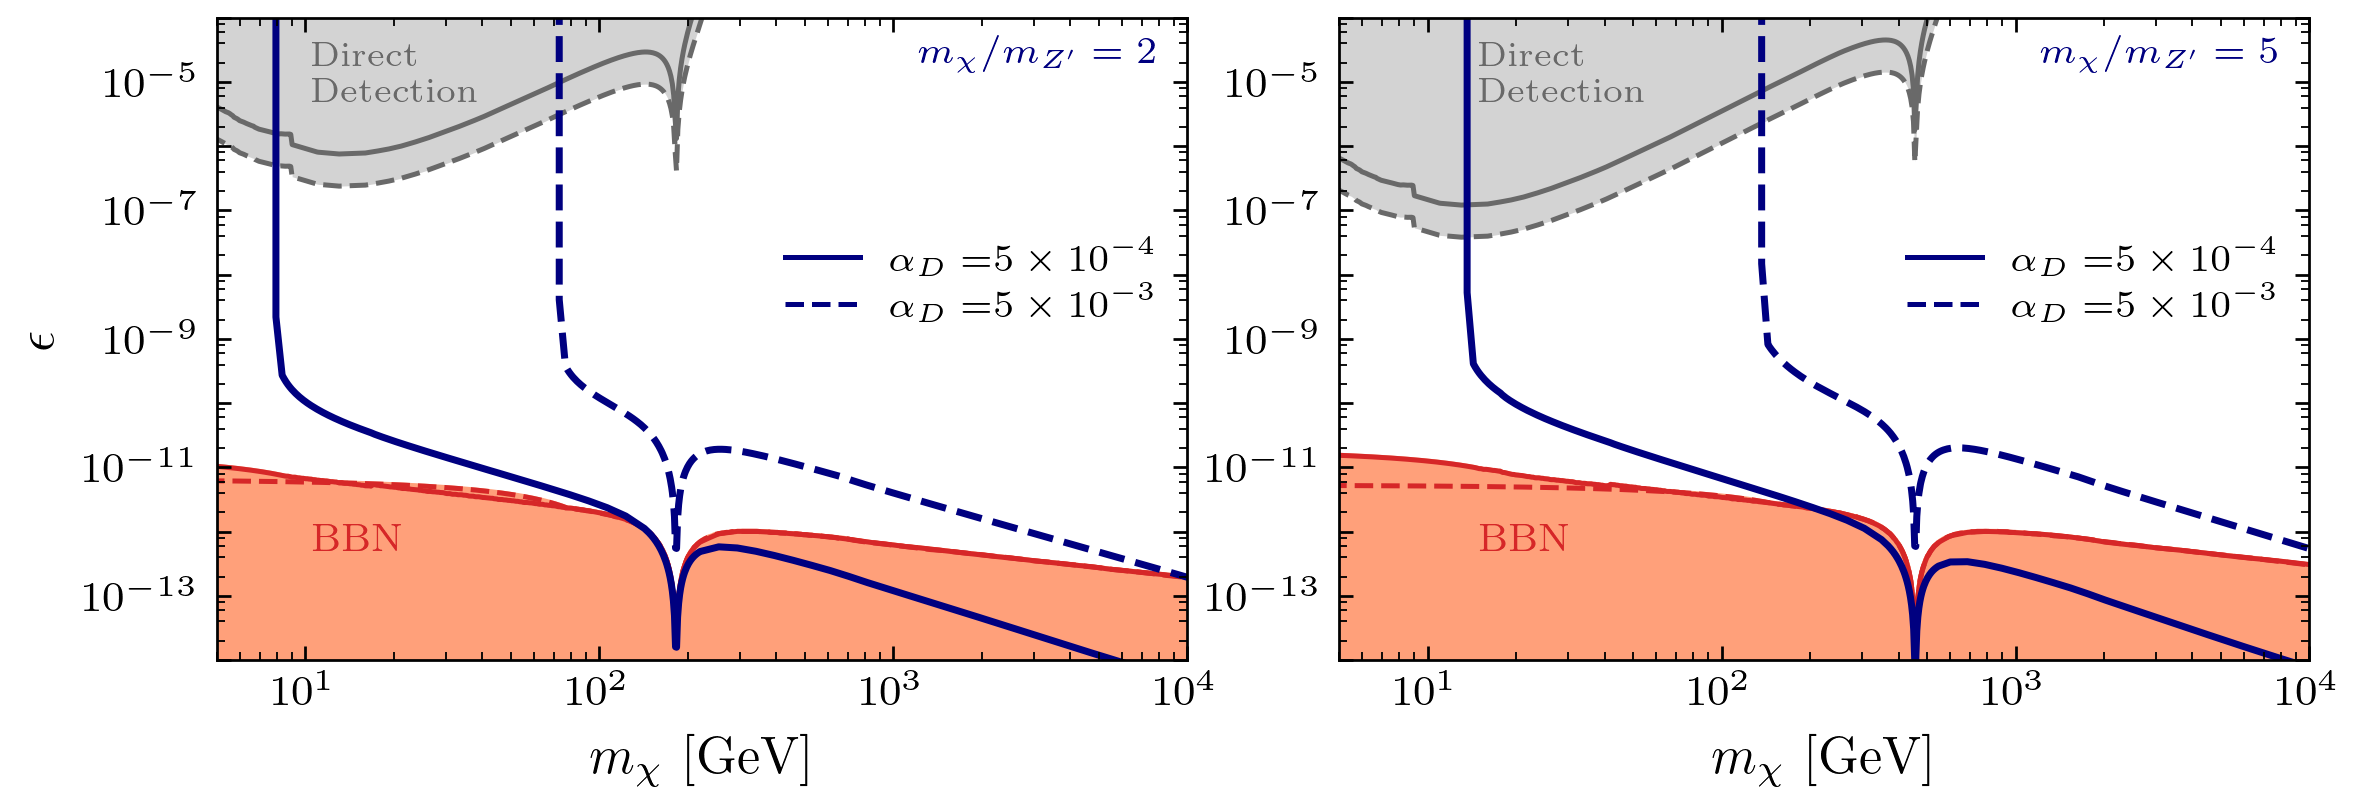

In [90]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.50))
gs1 = GridSpec(20,30,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:14])
ax2 = fig1.add_subplot(gs1[:,16:])
lss=['-','--', ':']
ZOs=[[-0.1,-.9],[-.1,-0.9],[-.1,-0.9]]
axs=[ax1,ax2]
for j in range(2):
    ax1.plot(dats[2*j]['mXs'],dats[2*j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax1.plot(np.NaN,np.NaN,lw=1,c='navy',ls=lss[j],label=r'$\alpha_D=$'+str(aXs_rs_tex[2*j][0]))
    ax2.plot(np.NaN,np.NaN,lw=1,c='navy',ls=lss[j],label=r'$\alpha_D=$'+str(aXs_rs_tex[2*j][0]))
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],0, dats[2*j]['epsXs_bbn'],lw=1,color='lightsalmon',alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_bbn'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    epsXs_DD = np.minimum(dats[2*j]['epsXs_LZ'], dats[2*j]['epsXs_XenT'])
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_LZ'],1,color='lightgrey',alpha=1,zorder=ZOs[j][1],lw=0)
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_XenT'],1,color='lightgrey',alpha=1,zorder=ZOs[j][1],lw=0)
    ax1.plot(dats[2*j]['mXs_bbn_dd'],epsXs_DD,lw=1,color='dimgrey',ls=lss[j],zorder=ZOs[j][1])
    #ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_XenT'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    #ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
    epsXs_DD = np.minimum(dats[2*j+1]['epsXs_LZ'], dats[2*j+1]['epsXs_XenT'])
    ax2.plot(dats[2*j+1]['mXs'],dats[2*j+1]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],0, dats[2*j+1]['epsXs_bbn'],lw=1,color='lightsalmon',alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_bbn'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_LZ'],1,color='lightgrey',alpha=1,zorder=ZOs[j][1],lw=0)
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_XenT'],1,color='lightgrey',alpha=1,zorder=ZOs[j][1],lw=0)
    ax2.plot(dats[2*j+1]['mXs_bbn_dd'],epsXs_DD,lw=1,color='dimgrey',ls=lss[j],zorder=ZOs[j][1])
    #ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel("$\epsilon$")
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-14,1e-4)
    ax.set_yticks([1e-14,1e-13,1e-12,1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4])
    ax.set_yticklabels(['',r'$10^{-13}$','',r'$10^{-11}$','',r'$10^{-9}$','',r'$10^{-7}$','',r'$10^{-5}$',''])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xscale("log")
    ax.set_xlim(5,1e4)
    ax.set_xlabel(r"$m_\chi$ [GeV]")
ax1.text(10.5,5e-6,"Direct\nDetection",fontsize=7,color='dimgrey')
ax2.text(15,5e-6,"Direct\nDetection",fontsize=7,color='dimgrey')
ax1.text(10.5,5e-13,"BBN",fontsize=8,color='tab:red')
ax2.text(15,5e-13,"BBN",fontsize=8,color='tab:red')
ax1.legend(loc=(.57,0.5))
ax2.legend(loc=(.57,0.5))
ax1.text(8e3,2e-5,r'$m_\chi/m_{Z^\prime}=2$',color='navy', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
ax2.text(8e3,2e-5,r'$m_\chi/m_{Z^\prime}=5$',color='navy', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
plt.savefig("../figs/vP_aX5e-4_5e-3_r2_5.png")
plt.savefig("../figs/vP_aX5e-4_5e-3_r2_5.pdf")
plt.show()
plt.close()

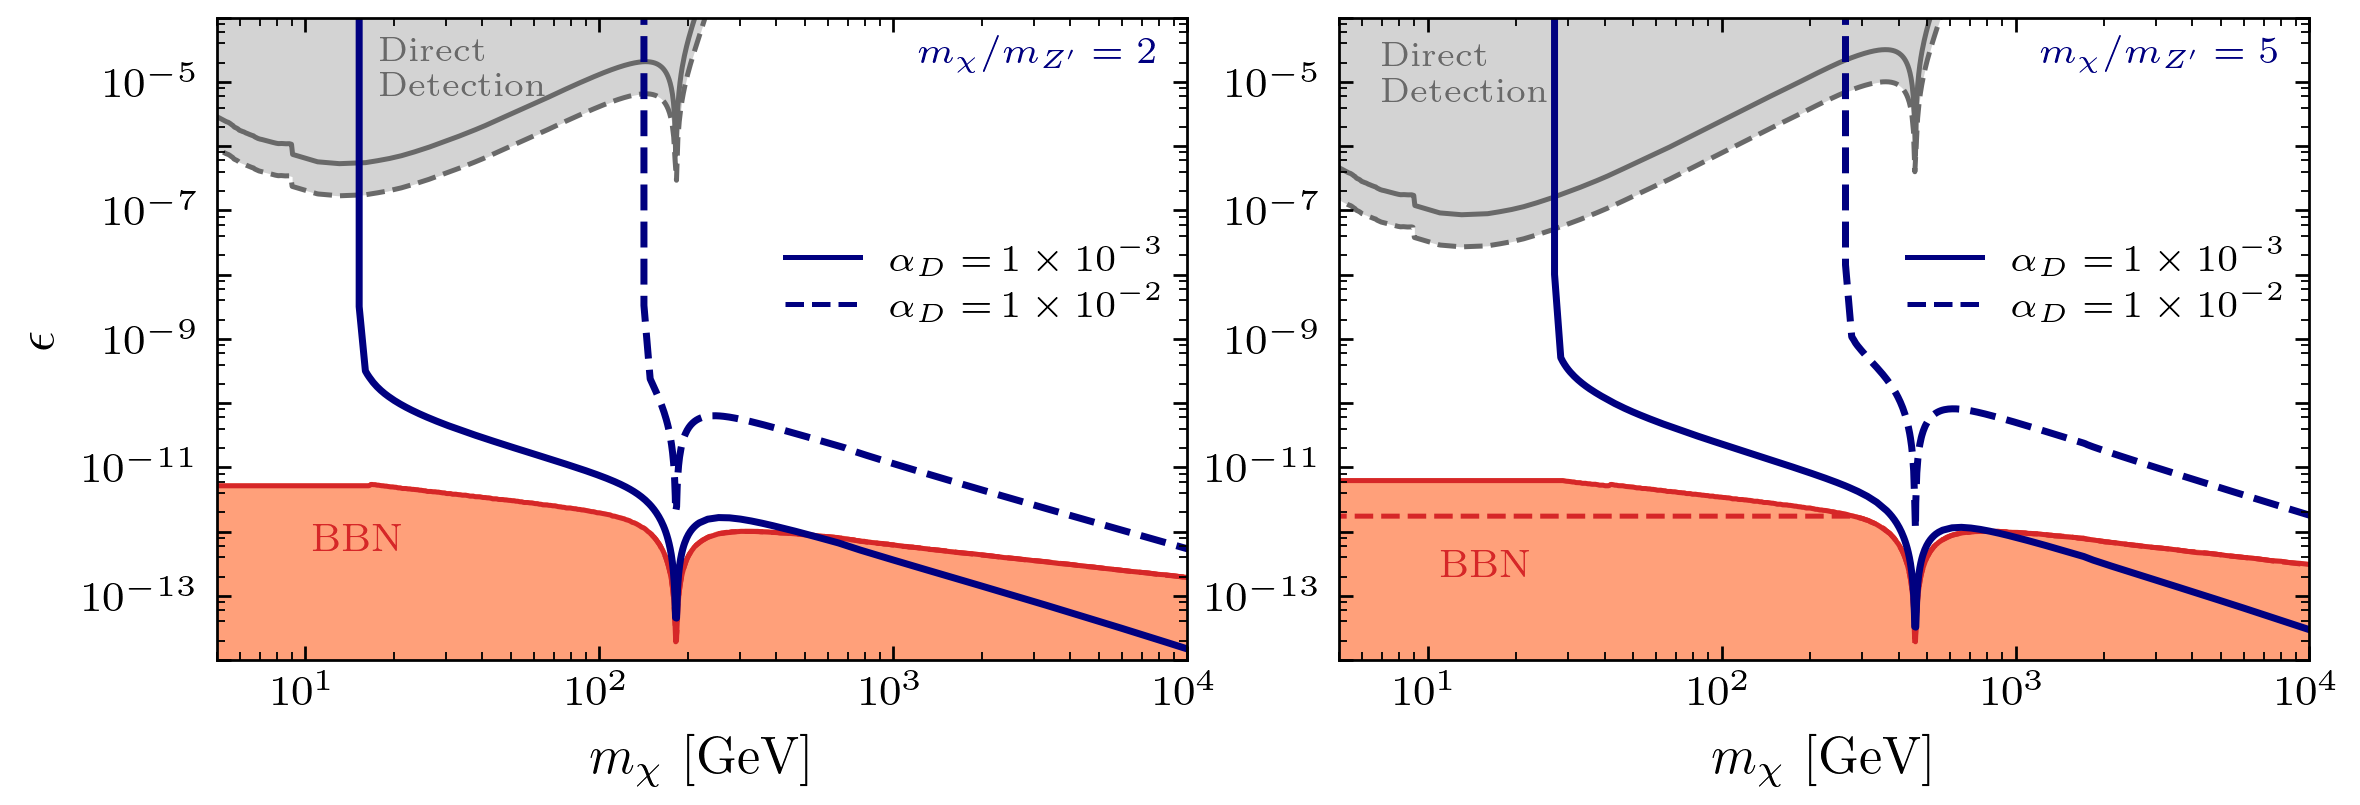

In [88]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.50))
gs1 = GridSpec(20,30,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:14])
ax2 = fig1.add_subplot(gs1[:,16:])
lss=['-','--', ':']
ZOs=[[-0.1,-.9],[-.1,-0.9],[-.1,-0.9]]
axs=[ax1,ax2]
for j in range(2):
    ax1.plot(dats[2*j]['mXs'],dats[2*j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax1.plot(np.NaN,np.NaN,lw=1,c='navy',ls=lss[j],label=r'$\alpha_D=\,$'+str(aXs_rs_tex[2*j][0]))
    ax2.plot(np.NaN,np.NaN,lw=1,c='navy',ls=lss[j],label=r'$\alpha_D=\,$'+str(aXs_rs_tex[2*j][0]))
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],0, dats[2*j]['epsXs_bbn'],lw=1,color='lightsalmon',alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_bbn'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    epsXs_DD = np.minimum(dats[2*j]['epsXs_LZ'], dats[2*j]['epsXs_XenT'])
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_LZ'],1,color='lightgrey',alpha=1,zorder=ZOs[j][1],lw=0)
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_XenT'],1,color='lightgrey',alpha=1,zorder=ZOs[j][1],lw=0)
    ax1.plot(dats[2*j]['mXs_bbn_dd'],epsXs_DD,lw=1,color='dimgrey',ls=lss[j],zorder=ZOs[j][1])
    #ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_XenT'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    #ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
    epsXs_DD = np.minimum(dats[2*j+1]['epsXs_LZ'], dats[2*j+1]['epsXs_XenT'])
    ax2.plot(dats[2*j+1]['mXs'],dats[2*j+1]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],0, dats[2*j+1]['epsXs_bbn'],lw=1,color='lightsalmon',alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_bbn'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_LZ'],1,color='lightgrey',alpha=1,zorder=ZOs[j][1],lw=0)
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_XenT'],1,color='lightgrey',alpha=1,zorder=ZOs[j][1],lw=0)
    ax2.plot(dats[2*j+1]['mXs_bbn_dd'],epsXs_DD,lw=1,color='dimgrey',ls=lss[j],zorder=ZOs[j][1])
    #ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel("$\epsilon$")
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-14,1e-4)
    ax.set_yticks([1e-14,1e-13,1e-12,1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4])
    ax.set_yticklabels(['',r'$10^{-13}$','',r'$10^{-11}$','',r'$10^{-9}$','',r'$10^{-7}$','',r'$10^{-5}$',''])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xscale("log")
    ax.set_xlim(5,1e4)
    ax.set_xlabel(r"$m_\chi$ [GeV]")
ax1.text(18,6e-6,"Direct\nDetection",fontsize=7,color='dimgrey')
ax2.text(7,5e-6,"Direct\nDetection",fontsize=7,color='dimgrey')
ax1.text(10.5,5e-13,"BBN",fontsize=8,color='tab:red')
ax2.text(11,2e-13,"BBN",fontsize=8,color='tab:red')
ax1.legend(loc=(.57,0.5))
ax2.legend(loc=(.57,0.5))
ax1.text(8e3,2e-5,r'$m_\chi/m_{Z^\prime}=2$',color='navy', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
ax2.text(8e3,2e-5,r'$m_\chi/m_{Z^\prime}=5$',color='navy', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
plt.savefig("../figs/vP_aX1e-3_1e-2_r2_5.png")
plt.savefig("../figs/vP_aX1e-3_1e-2_r2_5.pdf")
plt.show()
plt.close()

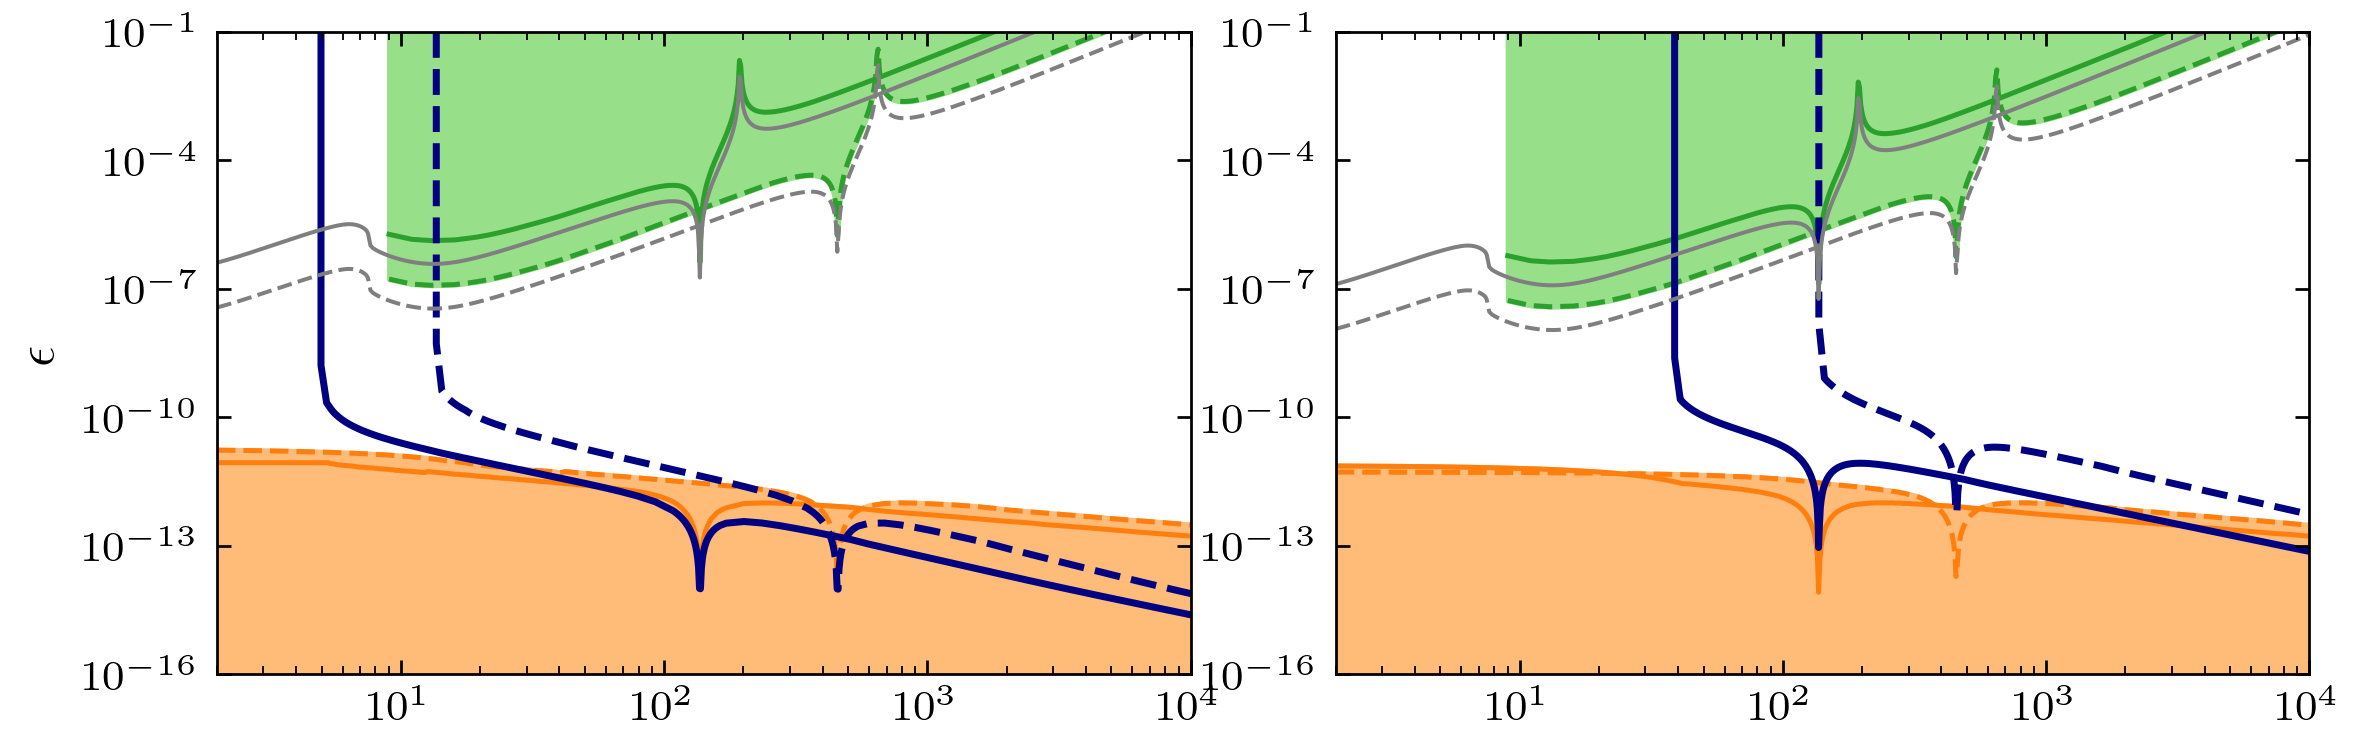

In [8]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(20,17,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:8])
ax2 = fig1.add_subplot(gs1[:,9:])
lss=['-','--', ':']
ZOs=[[-0.1,-.9],[-.1,-0.9],[-.1,-0.9]]
axs=[ax1,ax2]
for j in range(2):
    ax1.plot(dats[j]['mXs'],dats[j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax1.fill_between(dats[j]['mXs_bbn_dd'],0, dats[j]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    ax1.fill_between(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
    ax2.plot(dats[j+2]['mXs'],dats[j+2]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax2.fill_between(dats[j+2]['mXs_bbn_dd'],0, dats[j+2]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[j+2]['mXs_bbn_dd'],dats[j+2]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    ax2.fill_between(dats[j+2]['mXs_bbn_dd'],dats[j+2]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[j+2]['mXs_bbn_dd'],dats[j+2]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    ax2.plot(dats[j+2]['mXs_bbn_dd'],dats[j+2]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel("$\epsilon$")
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-16,1e-1)
    ax.set_xscale("log")
    ax.set_xlim(2,1e4)
#plt.savefig("../figs/vP_aX1e-3_5e-3_r1.5_5.png")
#plt.savefig("../figs/vP_aX1e-3_5e-3_r1.5_5.pdf")
plt.show()
plt.close()

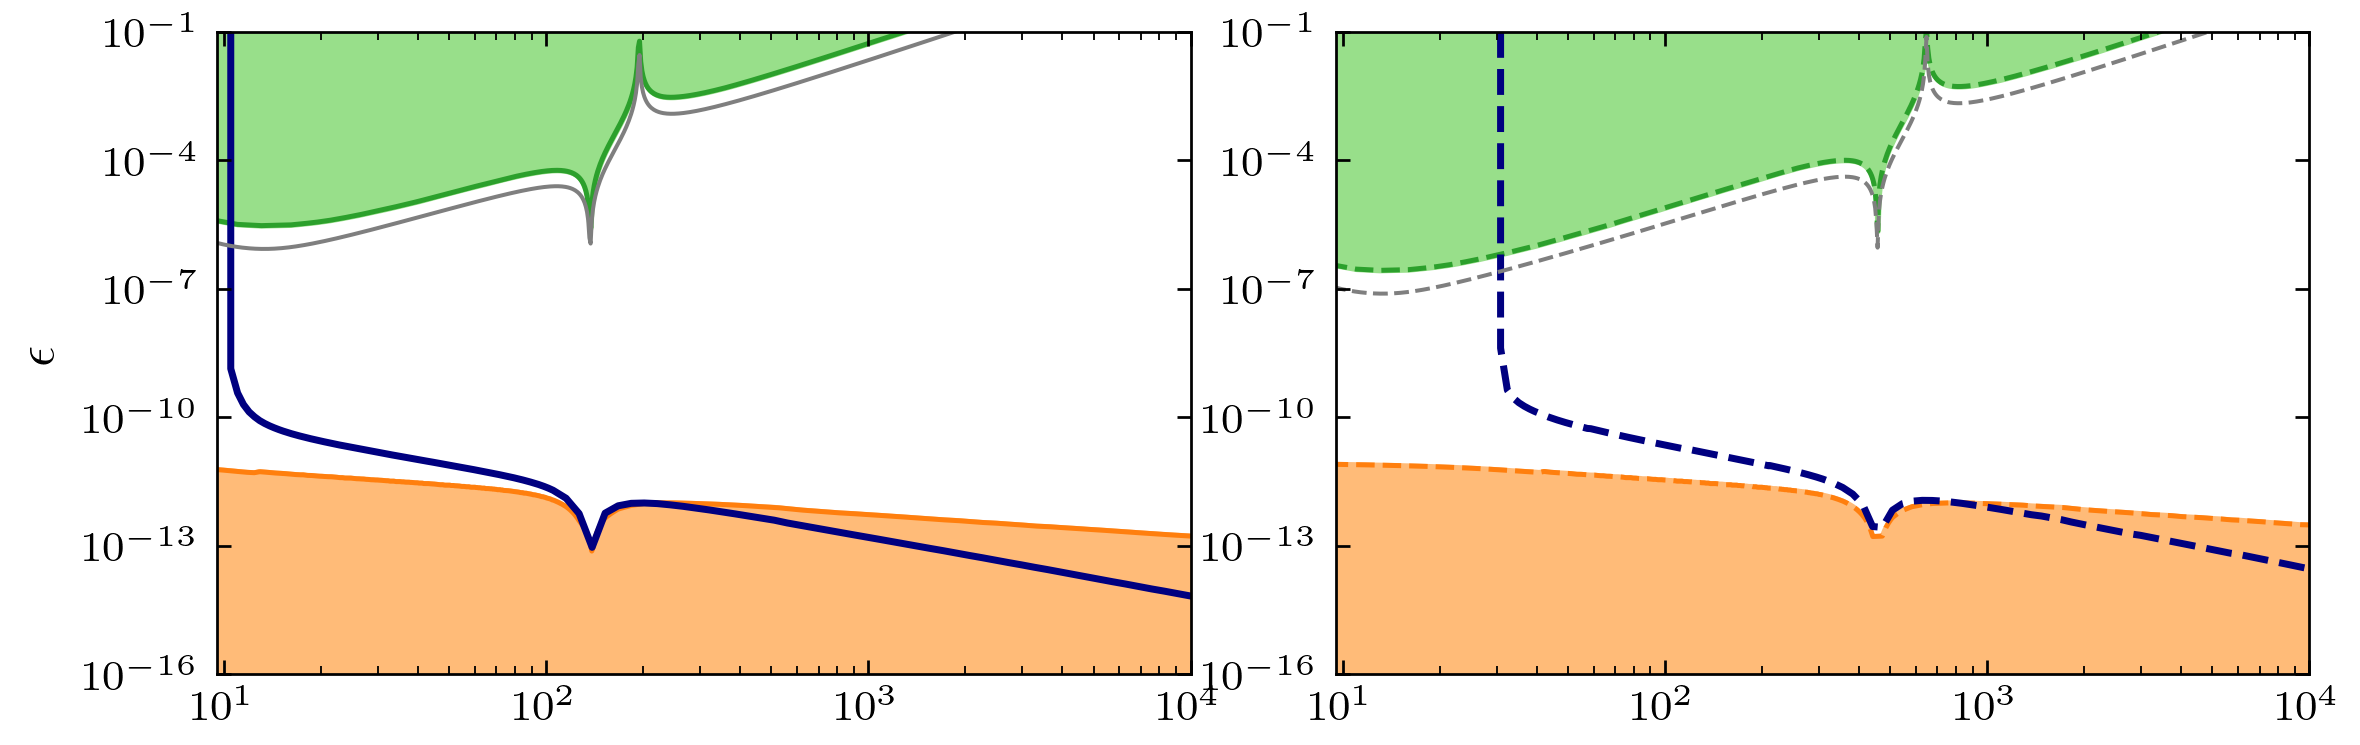

In [39]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(20,17,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:8])
ax2 = fig1.add_subplot(gs1[:,9:])
lss=['-','--']
#ZOs=[[-0.8,-.7],[-1,-0.9]]
ZOs=[[-0.1,-.9],[-.1,-0.9]]
axs=[ax1,ax2]
for j in range(2):
    axs[j].plot(dats[j]['mXs'],dats[j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    axs[j].fill_between(dats[j]['mXs_bbn_dd'],0, dats[j]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    axs[j].plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    axs[j].fill_between(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    axs[j].plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    axs[j].plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel("$\epsilon$")
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-16,1e-1)
    ax.set_xscale("log")
    ax.set_xlim(9.5,1e4)
#plt.savefig("../figs/vP_aX1e-3_5e-3_r1.5_5.png")
#plt.savefig("../figs/vP_aX1e-3_5e-3_r1.5_5.pdf")
plt.show()
plt.close()

In [ ]:
"""
axs=[ax1,ax2]
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-13,1e-4)
    ax.set_yticks([1e-13,1e-12,1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4])
    ax.set_yticklabels(['$10^{-13}$','','$10^{-11}$','','$10^{-9}$','','$10^{-7}$','','$10^{-5}$',''])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.plot(np.NaN,np.NaN,ls='-',lw=1,c='k',label='$m_\chi/m_{Z^\prime}=1.5$')
    ax.plot(np.NaN,np.NaN,ls='--',lw=1,c='k',label='$m_\chi/m_{Z^\prime}=5.0$')
    ax.legend()
    ax.set_xlabel(r"$m_\chi\,[{\rm GeV}]$")
ax1.set_title(r'$\alpha_D=1\times 10^{-3},\,\xi_{\rm infl}=1$',fontsize=9)
ax2.set_title(r'$\alpha_D=5\times 10^{-3},\,\xi_{\rm infl}=1$',fontsize=9)
ax1.set_xlim(np.min(dats[0]['mXs'])*0.9,np.max(dats[0]['mXs']))
ax2.set_xlim(np.min(dats[2]['mXs'])*0.9,np.max(dats[2]['mXs']))
ax1.text(50,4e-13,r"BBN",color=cs[2],fontsize=8)
ax2.text(200,2.5e-13,r"BBN",color=cs[2],fontsize=8)
ax1.text(30,1.2e-5,r"LZ (2025)",color=cs[4], fontsize=8)
ax2.text(200,2.2e-5,r"LZ (2025)",color=cs[4], fontsize=8)
ax1.text(40,4e-8,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=7)
ax1.text(40,1.2e-11,r"$\Omega_X\,h^2=0.12$",color='navy', fontsize=7, rotation=-5)
ax2.text(200,6e-7,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=7)
ax2.text(200,1.5e-11,r"$\Omega_X\,h^2=0.12$",color='navy', fontsize=7, rotation=-3)
"""

In [16]:
cosmo = Cosmology(gstar_choice="standard", gstarpath="./")

cases = [
    (1e-4, 5.0),
    (1e-2, 5.0),
]

for alphaX, r in cases:
    print(f"\n=== VectorPortal: alphaX={alphaX:.0e}, r={r} ===")
    model_factory = lambda mX, mY, aX=alphaX: VectorPortal(
        mX=mX, mY=mY, gX=2, gY=3, alphaX=aX,
        include_antiparticlesX=True, include_antiparticlesY=False)

    res = find_mXstar(cosmo, model_factory, r=r, verbose=True, verbose_solver=True)
    print(f"mXstar={res['mXstar']:.6e}, epsX_min={res['epsX_min']:.6e}")
    break


=== VectorPortal: alphaX=1e-04, r=5.0 ===
find_mXstar  (r=5.00)
  mX_est = 5.78e+00 GeV  bracket = [5.78e-01, 2.89e+01]
------------------------------------------------------------
Boltzmann Solver -- QSSA Three-Phase
  mX = 5.78e-01 GeV, mY = 1.16e-01 GeV, r = 5.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:   5%|█████▎                                                                                            | 7/130 [00:01<00:21,  5.66it/s]


  -> Phase 1.5 (QSSA) at x = 1.95 (Gamma_ann = 2.9e+09)


Evolving:  18%|█████████████████▏                                                                               | 23/130 [00:03<00:07, 14.84it/s]


  -> Phase 2 (full) at x = 9.99 (Gamma_can=6.9e-01, muX=0.00)


...


  -> Phase 1.5 (QSSA) at x = 0.99 (Gamma_ann = 3.3e+09)


Evolving:  20%|███████████████████▍                                                                             | 26/130 [00:02<00:05, 17.91it/s]


  -> Phase 2 (full) at x = 12.49 (Gamma_can=7.6e-01, muX=0.00)


Evolving:  87%|██████████████████████████████████████████████████▍       | 113/130 [00:04<00:00, 25.42it/s, ph=2, x=200, muX=2853.1, dev=8.8e-03]



  Converged (2, dlnxi_NR) at x = 199.8
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 0.99
  x_switch (QSSA -> full): 12.49
  x_FO (muX > 0.05): 12.7
  Converged: True at x = 199.8
  YX_relic = 2.277551e-10
  => epsX_min = 2.4655e-09  (dS/S < 0.001)  SRatio_plateau = 1.4359
mXstar=2.688549e+00, epsX_min=2.465461e-09


In [19]:
rv=5
mXv=2.688549e+00 * (1 + 5e-2)
mYv=mXv/rv
alphaXv=1e-4
model = VectorPortal(
    mX=mXv, mY=mYv, gX=2, gY=3, alphaX=alphaXv,
    include_antiparticlesX=True, include_antiparticlesY=False)
solver = BoltzmannSolver(cosmo, model)
sol0 = solver.solve_boltzmann_chempot_3phase(
    return_bg_ICs=True, verbose=True,
    cannibal_switch_full=1, convergence_threshold=2e-2)
epsXv = solver.find_epsilon_DMRelic(
    sol0['bg_ICs'], log10eps_range=(-18, -8), root_rtol=1e-4)
epsXv_bbn = solver.find_epsilon_BBN_hadronic(
    sol0['YY_final'], log10eps_range=(-20, -9), root_rtol=1e-3)
print(epsXv, epsXv_bbn)


Boltzmann Solver -- QSSA Three-Phase
  mX = 2.82e+00 GeV, mY = 5.65e-01 GeV, r = 5.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.02
------------------------------------------------------------


Evolving:   4%|███▊                                                                                              | 5/130 [00:01<00:30,  4.12it/s]


  -> Phase 1.5 (QSSA) at x = 0.99 (Gamma_ann = 3.1e+09)


Evolving:  20%|███████████████████▍                                                                             | 26/130 [00:02<00:05, 18.64it/s]


  -> Phase 2 (full) at x = 12.49 (Gamma_can=8.7e-01, muX=0.00)


Evolving:  87%|██████████████████████████████████████████████████▍       | 113/130 [00:04<00:00, 26.24it/s, ph=2, x=200, muX=2875.8, dev=8.7e-03]



  Converged (2, dlnxi_NR) at x = 199.8
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 0.99
  x_switch (QSSA -> full): 12.49
  x_FO (muX > 0.05): 12.7
  Converged: True at x = 199.8
  YX_relic = 2.365806e-10
4.895067592109256e-10 2.487782186776431e-11
